# Extended-Tau Verification: Stages 08-10

This notebook verifies the long-tau rerun chain and compares it to the original Stage 08-10 artifacts.

Expected long-tau artifacts:

- `cache/08_pdet_grid_tau1000_v1.h5`
- `cache/08_pdet_grid_tau1000_summary.json`
- `cache/09_characterization_probability_tau1000_v1.h5`
- `cache/09_characterization_probability_tau1000_summary.json`
- `cache/10_validation_sensitivity_tau1000_summary.json`
- `cache/10_completeness_statement_tau1000.md`

If these files do not exist yet, run the long-tau scripts from the repo root:

```bash
bash trap_completeness_method3/src/run_full_pdet_grid_extended_tau.sh
bash trap_completeness_method3/src/run_characterization_probability_extended_tau.sh --smoke
bash trap_completeness_method3/src/run_characterization_probability_extended_tau.sh
bash trap_completeness_method3/src/run_validation_sensitivity_extended_tau.sh
```

## What To Check

The extended-tau rerun is meant to answer whether the old Stage 08 upper boundary at `tau = 20 s` was artificially truncating long-lived trap sensitivity.

Human checks:

- Stage 08 long-tau grid should extend beyond `20 s`, by default to `1000 s`.
- Stage 09 tau out-of-band fraction should decrease relative to the original map, especially in the long-`tau_135` wedge.
- Stage 10 completeness-vs-`tau_135` should show whether the long-tau completeness tail moves upward.
- Known-trap validation should remain high.
- Any remaining all-temperatures-out-of-band region is now more likely a real measurement limitation, not just the old Stage 08 grid edge.

In [1]:
from pathlib import Path
import json

import h5py
import numpy as np


def find_repo_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "trap_completeness_method3" / "README.md").exists():
            return candidate
    raise RuntimeError("Could not find repo root from current working directory")


repo = find_repo_root()
work = repo / "trap_completeness_method3"
cache = work / "cache"
figures = cache / "figures"
figures.mkdir(exist_ok=True)

baseline = {
    "stage08_h5": cache / "08_pdet_grid_v1.h5",
    "stage08_summary": cache / "08_pdet_grid_summary.json",
    "stage09_h5": cache / "09_characterization_probability_v1.h5",
    "stage09_summary": cache / "09_characterization_probability_summary.json",
    "stage10_summary": cache / "10_validation_sensitivity_summary.json",
    "stage10_statement": cache / "10_completeness_statement.md",
}

extended = {
    "stage08_h5": cache / "08_pdet_grid_tau1000_v1.h5",
    "stage08_summary": cache / "08_pdet_grid_tau1000_summary.json",
    "stage09_h5": cache / "09_characterization_probability_tau1000_v1.h5",
    "stage09_summary": cache / "09_characterization_probability_tau1000_summary.json",
    "stage10_summary": cache / "10_validation_sensitivity_tau1000_summary.json",
    "stage10_statement": cache / "10_completeness_statement_tau1000.md",
}

for label, paths in [("baseline", baseline), ("extended", extended)]:
    print("\n" + label)
    for name, path in paths.items():
        status = "OK" if path.exists() else "MISSING"
        size = f"{path.stat().st_size / 1024:.1f} KiB" if path.exists() else ""
        print(f"{name:16s} {status:8s} {path.relative_to(repo)} {size}")

missing = [path for path in extended.values() if not path.exists()]
if missing:
    raise FileNotFoundError("Run the long-tau scripts first. Missing: " + ", ".join(str(p.relative_to(repo)) for p in missing))


baseline
stage08_h5       OK       trap_completeness_method3\cache\08_pdet_grid_v1.h5 1045.8 KiB
stage08_summary  OK       trap_completeness_method3\cache\08_pdet_grid_summary.json 14.2 KiB
stage09_h5       OK       trap_completeness_method3\cache\09_characterization_probability_v1.h5 926.7 KiB
stage09_summary  OK       trap_completeness_method3\cache\09_characterization_probability_summary.json 56.2 KiB
stage10_summary  OK       trap_completeness_method3\cache\10_validation_sensitivity_summary.json 24.5 KiB
stage10_statement OK       trap_completeness_method3\cache\10_completeness_statement.md 1.8 KiB

extended
stage08_h5       OK       trap_completeness_method3\cache\08_pdet_grid_tau1000_v1.h5 1439.5 KiB
stage08_summary  OK       trap_completeness_method3\cache\08_pdet_grid_tau1000_summary.json 14.9 KiB
stage09_h5       OK       trap_completeness_method3\cache\09_characterization_probability_tau1000_v1.h5 926.7 KiB
stage09_summary  OK       trap_completeness_method3\cache\09_charact

## Load Summaries And HDF5 Grids

In [2]:
def load_json(path):
    with path.open("r", encoding="utf-8") as handle:
        return json.load(handle)


def load_stage08(path):
    with h5py.File(path, "r") as h5:
        return {
            "temperature": h5["grid/temperature_K"][:],
            "tau": h5["grid/tau_seconds"][:],
            "amplitude": h5["grid/amplitude_electrons"][:],
            "p_det": h5["results/p_det"][:],
        }


def load_stage09(path):
    with h5py.File(path, "r") as h5:
        return {
            "tau_135": h5["grid/tau_135_seconds"][:],
            "E": h5["grid/E_eV"][:],
            "p4": h5["results/p_characterized_n_good_4"][:],
            "p3": h5["results/p_characterized_n_good_3"][:],
            "tau_oob": h5["diagnostics/tau_oob_fraction"][:],
            "all_oob": h5["diagnostics/all_temperatures_tau_oob"][:].astype(bool),
            "known_p4": h5["validation_known_traps/n_good_4_csv/p_characterized_n_good_4"][:],
            "known_p3": h5["validation_known_traps/n_good_3_csv/p_characterized_n_good_3"][:],
        }


b08 = load_stage08(baseline["stage08_h5"])
x08 = load_stage08(extended["stage08_h5"])
b09 = load_stage09(baseline["stage09_h5"])
x09 = load_stage09(extended["stage09_h5"])
b08s = load_json(baseline["stage08_summary"])
x08s = load_json(extended["stage08_summary"])
b09s = load_json(baseline["stage09_summary"])
x09s = load_json(extended["stage09_summary"])
b10s = load_json(baseline["stage10_summary"])
x10s = load_json(extended["stage10_summary"])

print("baseline Stage 08 tau:", b08["tau"][0], b08["tau"][-1], len(b08["tau"]))
print("extended Stage 08 tau:", x08["tau"][0], x08["tau"][-1], len(x08["tau"]))
print("baseline Stage 09 p4 shape:", b09["p4"].shape)
print("extended Stage 09 p4 shape:", x09["p4"].shape)

assert x08["tau"][-1] > b08["tau"][-1]
assert np.isclose(x08["tau"][-1], 1000.0) or x08["tau"][-1] > 20.0
assert b09["p4"].shape == x09["p4"].shape
assert np.allclose(b09["tau_135"], x09["tau_135"])
assert np.allclose(b09["E"], x09["E"])
print("Core grid checks passed.")

baseline Stage 08 tau: 2e-05 20.0 55
extended Stage 08 tau: 2e-05 1000.0 79
baseline Stage 09 p4 shape: (161, 121)
extended Stage 09 p4 shape: (161, 121)
Core grid checks passed.


## Required Validation Checks

These should remain true after extending the tau grid.

In [3]:
print("Stage 08 checks:")
print(json.dumps(x08s["required_checks"], indent=2))
print("\nStage 09 algebra:", x09s["algebra_check"])
print("Stage 09 Poisson max error:", x09s["poisson_binomial_tests"]["max_abs_error"])
print("\nStage 10 checks:")
print(json.dumps(x10s["required_checks"], indent=2))

assert all(value == "PASS" for value in x08s["required_checks"].values())
assert x09s["algebra_check"]["passed"]
assert x09s["poisson_binomial_tests"]["passed"]
assert all(value == "PASS" for value in x10s["required_checks"].values())
print("All extended-chain checks passed.")

Stage 08 checks:
{
  "all_23_measurement_temperatures_have_detection_grid": "PASS",
  "april_only_200k_grid_and_image_sigma_applied": "PASS",
  "controlling_cutflow_fractions_sum_to_one": "PASS",
  "exact_and_fallback_noise_draw_counts_stored_by_temperature": "PASS",
  "primary_grid_has_no_explicit_sigma_axis": "PASS"
}

Stage 09 algebra: {'formula': 'log_sigma = log_energy_cross_section(135, E, 0) - log(tau_135)', 'max_abs_log_tau_error': 7.105427357601002e-15, 'median_abs_log_tau_error': 1.7763568394002505e-15, 'passed': True}
Stage 09 Poisson max error: 1.3877787807814457e-16

Stage 10 checks:
{
  "known_characterized_traps_mostly_high_probability": "PASS",
  "sensitivity_variants_are_numerical": "PASS",
  "final_claim_conditional_on_amplitude_prior_and_observed_E": "PASS",
  "recoverable_completeness_distinguished_from_unconditional_population_bound": "PASS"
}
All extended-chain checks passed.


## Did The Long-Tau Extension Reduce Out-Of-Band Support?

This is the main diagnostic. The extended grid should reduce `tau_out_of_grid_fraction` and the all-temperatures-out-of-band region if the old `20 s` boundary was important.

In [4]:
rows = []
for label, s09 in [("baseline", b09s), ("extended", x09s)]:
    out = s09["interpolation_out_of_range"]
    unbounded = s09["all_temperatures_out_of_band_regime"]
    rows.append({
        "label": label,
        "tau_out_of_grid_fraction": out["tau_out_of_grid_fraction"],
        "all_temperatures_oob_fraction": out["all_temperatures_tau_out_of_grid_fraction"],
        "pdet_zeroed_by_tau_fraction": out["pdet_queries_zeroed_by_tau_fraction"],
        "unbounded_grid_fraction": unbounded["all_temperatures_out_of_band_grid_fraction"],
        "max_p4_all_oob": unbounded["max_p4_when_all_temperatures_out_of_band"],
    })

for row in rows:
    print(row)

print("\nReduction in tau_out_of_grid_fraction:", rows[0]["tau_out_of_grid_fraction"] - rows[1]["tau_out_of_grid_fraction"])
print("Reduction in all-temperatures OOB fraction:", rows[0]["all_temperatures_oob_fraction"] - rows[1]["all_temperatures_oob_fraction"])

{'label': 'baseline', 'tau_out_of_grid_fraction': 0.5256827722887183, 'all_temperatures_oob_fraction': 0.16133668702838663, 'pdet_zeroed_by_tau_fraction': 0.5256827722887183, 'unbounded_grid_fraction': 0.16133668702838663, 'max_p4_all_oob': 0.0}
{'label': 'extended', 'tau_out_of_grid_fraction': 0.40755429482014804, 'all_temperatures_oob_fraction': 0.08110466608490324, 'pdet_zeroed_by_tau_fraction': 0.40755429482014804, 'unbounded_grid_fraction': 0.08110466608490324, 'max_p4_all_oob': 0.0}

Reduction in tau_out_of_grid_fraction: 0.11812847746857025
Reduction in all-temperatures OOB fraction: 0.08023202094348339


## Compare Characterization Maps

In [5]:
diff_p4 = x09["p4"] - b09["p4"]
diff_oob = x09["tau_oob"] - b09["tau_oob"]

print("p4 baseline median/mean:", np.median(b09["p4"]), np.mean(b09["p4"]))
print("p4 extended median/mean:", np.median(x09["p4"]), np.mean(x09["p4"]))
print("p4 diff min/median/mean/max:", np.min(diff_p4), np.median(diff_p4), np.mean(diff_p4), np.max(diff_p4))
print("fraction of grid where p4 increased by >0.05:", np.mean(diff_p4 > 0.05))
print("fraction of grid where p4 increased by >0.20:", np.mean(diff_p4 > 0.20))
print("tau_oob diff min/median/mean/max:", np.min(diff_oob), np.median(diff_oob), np.mean(diff_oob), np.max(diff_oob))

assert np.all((x09["p4"] >= 0) & (x09["p4"] <= 1))
assert np.all((x09["p3"] >= 0) & (x09["p3"] <= 1))

p4 baseline median/mean: 0.9978735282062214 0.7347897736196607
p4 extended median/mean: 0.9977965914522962 0.7347078857589897
p4 diff min/median/mean/max: -0.04544462242194447 1.7945422925436105e-11 -8.188786067101105e-05 0.047050360290495974
fraction of grid where p4 increased by >0.05: 0.0
fraction of grid where p4 increased by >0.20: 0.0
tau_oob diff min/median/mean/max: -1.0 -0.08695652173913043 -0.11812847746857025 0.0


saved trap_completeness_method3\cache\figures\11_extended_tau_stage09_comparison.png


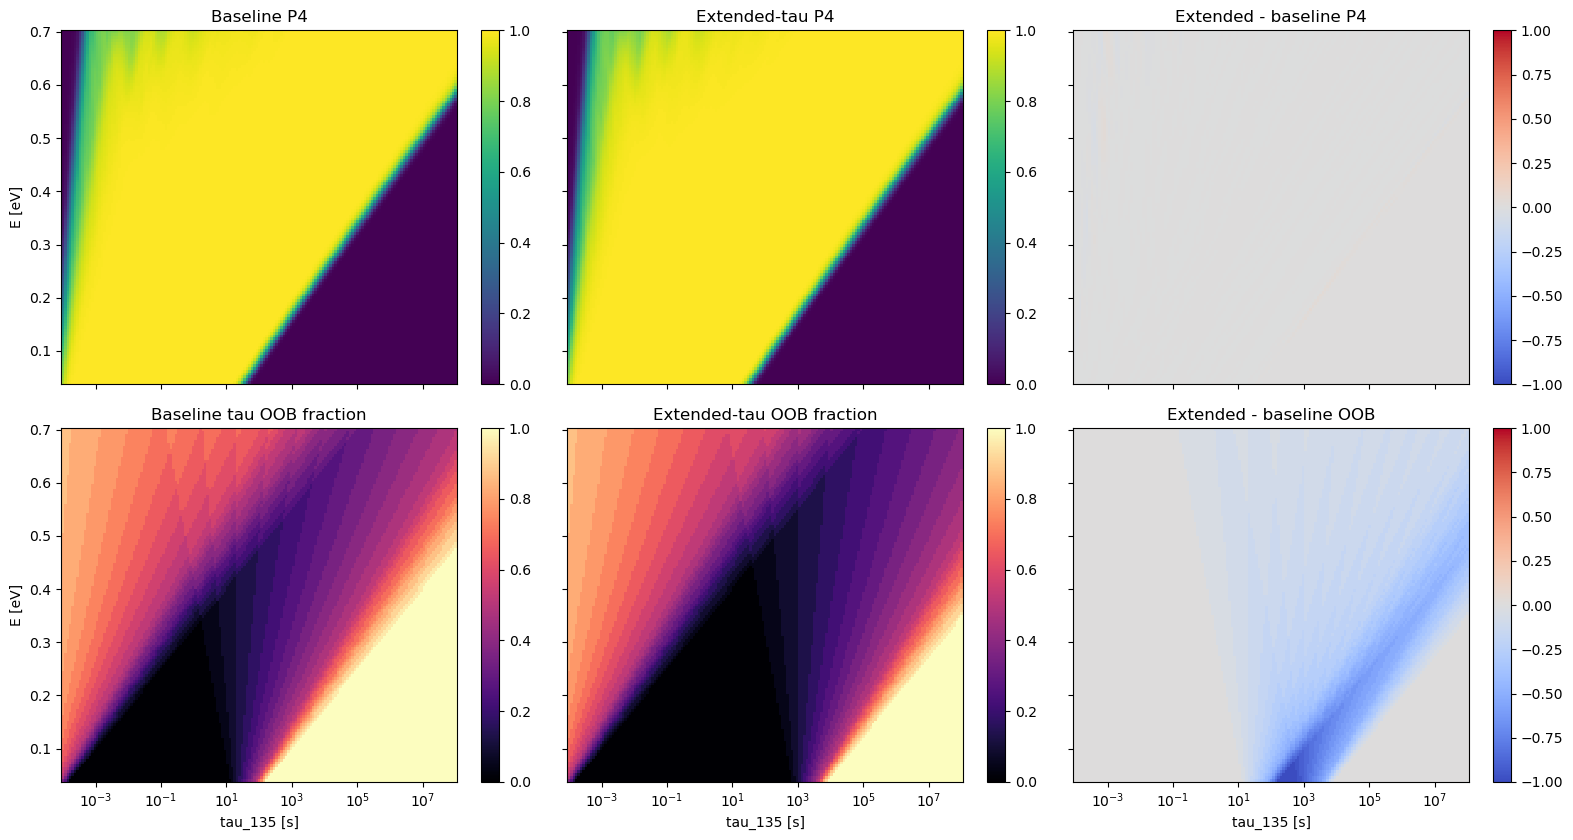

In [6]:
import matplotlib.pyplot as plt

tau_135 = b09["tau_135"]
E = b09["E"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8.5), sharex=True, sharey=True)
panels = [
    (axes[0, 0], b09["p4"], "Baseline P4", "viridis", 0, 1),
    (axes[0, 1], x09["p4"], "Extended-tau P4", "viridis", 0, 1),
    (axes[0, 2], diff_p4, "Extended - baseline P4", "coolwarm", -1, 1),
    (axes[1, 0], b09["tau_oob"], "Baseline tau OOB fraction", "magma", 0, 1),
    (axes[1, 1], x09["tau_oob"], "Extended-tau OOB fraction", "magma", 0, 1),
    (axes[1, 2], diff_oob, "Extended - baseline OOB", "coolwarm", -1, 1),
]
for ax, data, title, cmap, vmin, vmax in panels:
    mesh = ax.pcolormesh(tau_135, E, data.T, shading="auto", cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_xscale("log")
    ax.set_title(title)
    fig.colorbar(mesh, ax=ax)
for ax in axes[-1, :]:
    ax.set_xlabel("tau_135 [s]")
for ax in axes[:, 0]:
    ax.set_ylabel("E [eV]")
fig.tight_layout()
out = figures / "11_extended_tau_stage09_comparison.png"
fig.savefig(out, dpi=180)
print("saved", out.relative_to(repo))

## Compare Stage 10 Completeness Curves

Stage 10 stores representative values and intervals in JSON, but not the full curves. The cached Stage 10 figure is therefore the easiest visual check. This cell also prints the numerical comparisons at representative `tau_135` values.

In [7]:
def representative(summary, variant="default_n_good_4"):
    return summary["completeness_vs_tau_observed_E"][variant]["representative_tau_seconds_to_mean_probability"]


b_rep = representative(b10s)
x_rep = representative(x10s)
for tau_key in ["0.001", "0.01", "0.1", "1", "10", "100", "1000", "10000", "100000", "1e+06", "1e+07", "1e+08"]:
    if tau_key in b_rep and tau_key in x_rep:
        print(f"tau={tau_key:>7s} baseline={b_rep[tau_key]:.6f} extended={x_rep[tau_key]:.6f} delta={x_rep[tau_key]-b_rep[tau_key]:+.6f}")

print("\nBaseline >=90% intervals:")
print(b10s["completeness_vs_tau_observed_E"]["default_n_good_4"]["tau_intervals_mean_probability_ge_0p90"])
print("\nExtended >=90% intervals:")
print(x10s["completeness_vs_tau_observed_E"]["default_n_good_4"]["tau_intervals_mean_probability_ge_0p90"])

tau=  0.001 baseline=0.983299 extended=0.982190 delta=-0.001109
tau=   0.01 baseline=0.999391 extended=0.999392 delta=+0.000000
tau=    0.1 baseline=0.999843 extended=0.999856 delta=+0.000013
tau=      1 baseline=0.999948 extended=0.999946 delta=-0.000002
tau=     10 baseline=0.999982 extended=0.999983 delta=+0.000001
tau=    100 baseline=0.994619 extended=0.994645 delta=+0.000026
tau=   1000 baseline=0.935810 extended=0.936389 delta=+0.000578
tau=  10000 baseline=0.685617 extended=0.688035 delta=+0.002417
tau= 100000 baseline=0.079894 extended=0.081349 delta=+0.001455
tau=  1e+06 baseline=0.014691 extended=0.014722 delta=+0.000031
tau=  1e+07 baseline=0.007081 extended=0.007108 delta=+0.000027
tau=  1e+08 baseline=0.001092 extended=0.001090 delta=-0.000002

Baseline >=90% intervals:
[{'tau_min_seconds': 0.00039810717055349735, 'tau_max_seconds': 1584.8931924611109, 'grid_count': 89}]

Extended >=90% intervals:
[{'tau_min_seconds': 0.00039810717055349735, 'tau_max_seconds': 1584.893192

trap_completeness_method3\cache\figures\10_completeness_vs_tau.png True


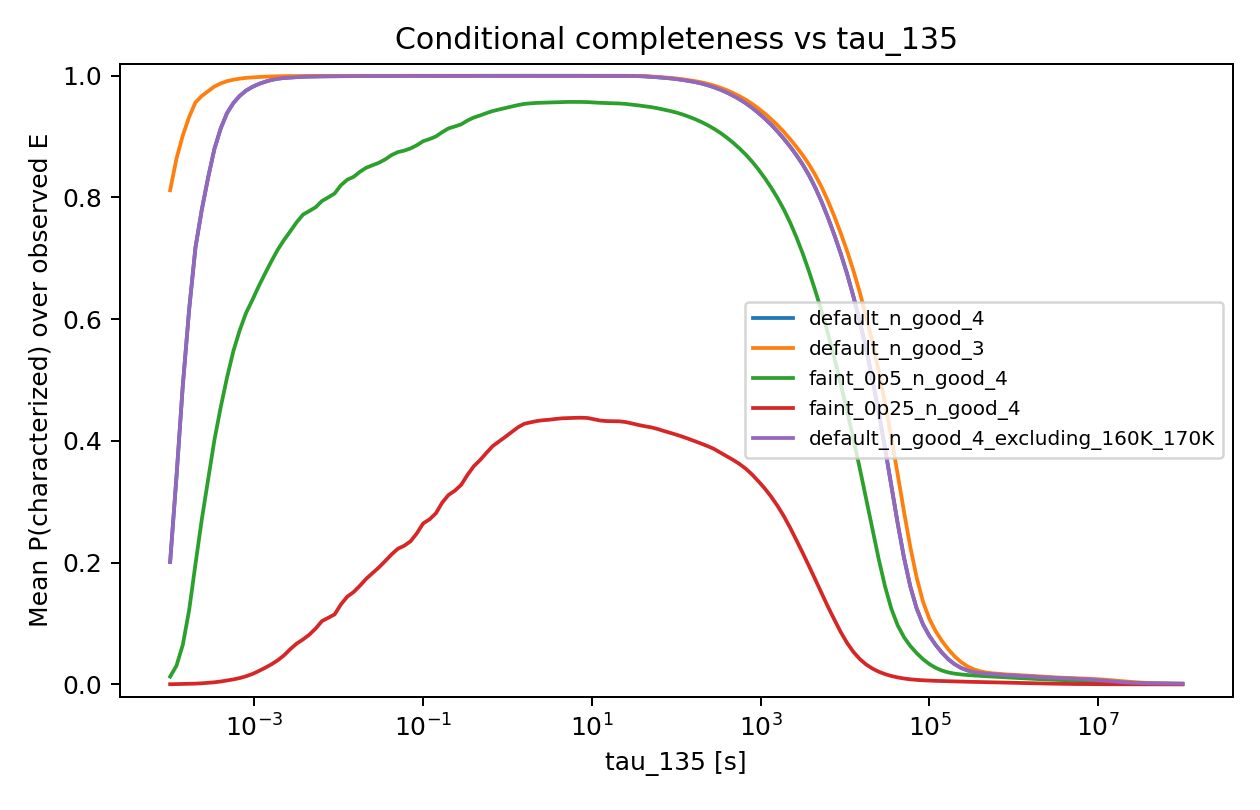

trap_completeness_method3\cache\figures\10_tau1000_completeness_vs_tau.png True


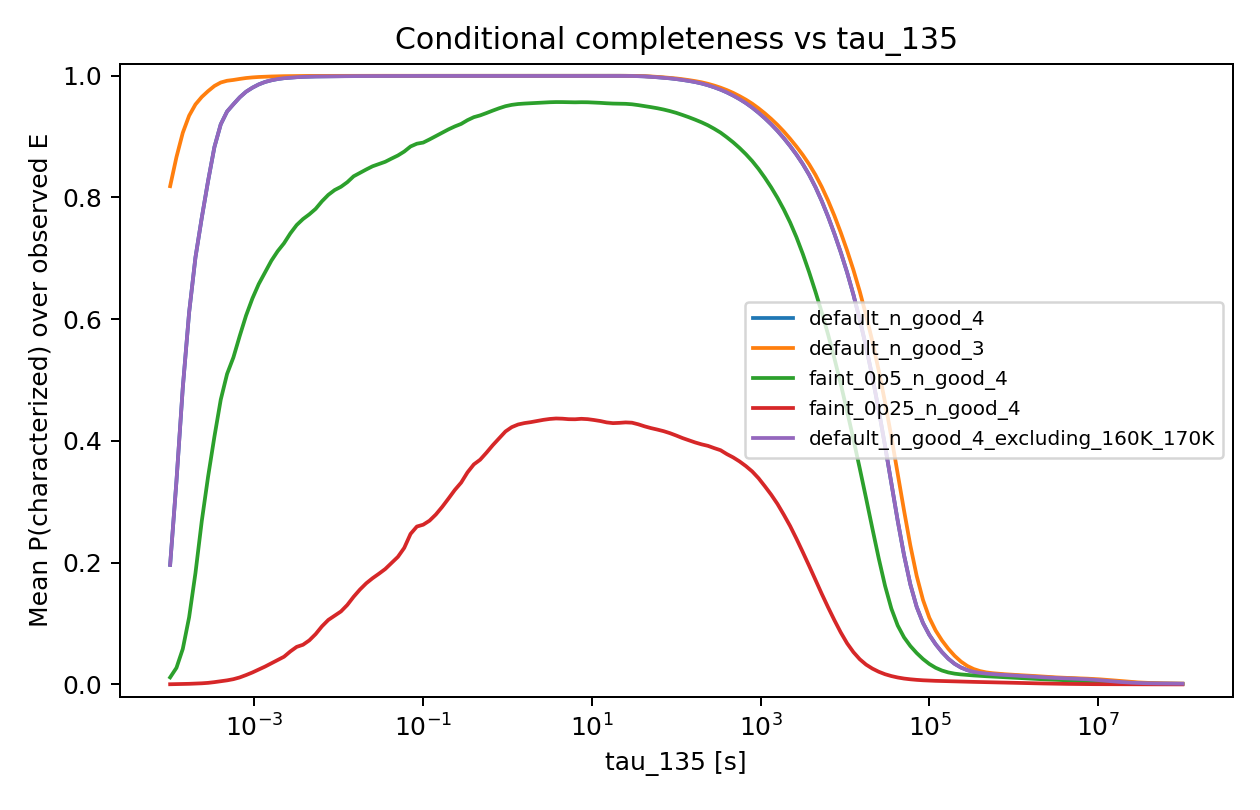

trap_completeness_method3\cache\figures\10_tau1000_known_trap_probability_hist.png True


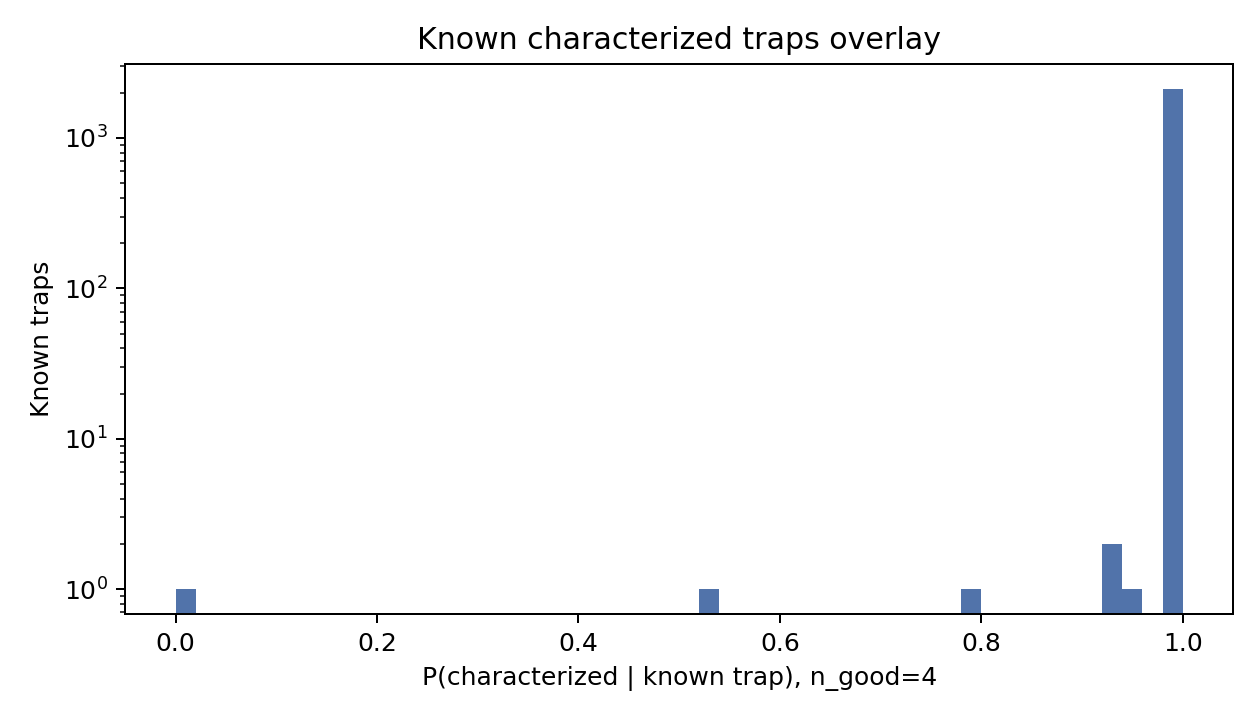

trap_completeness_method3\cache\figures\10_tau1000_method2_vs_method3_hist.png True


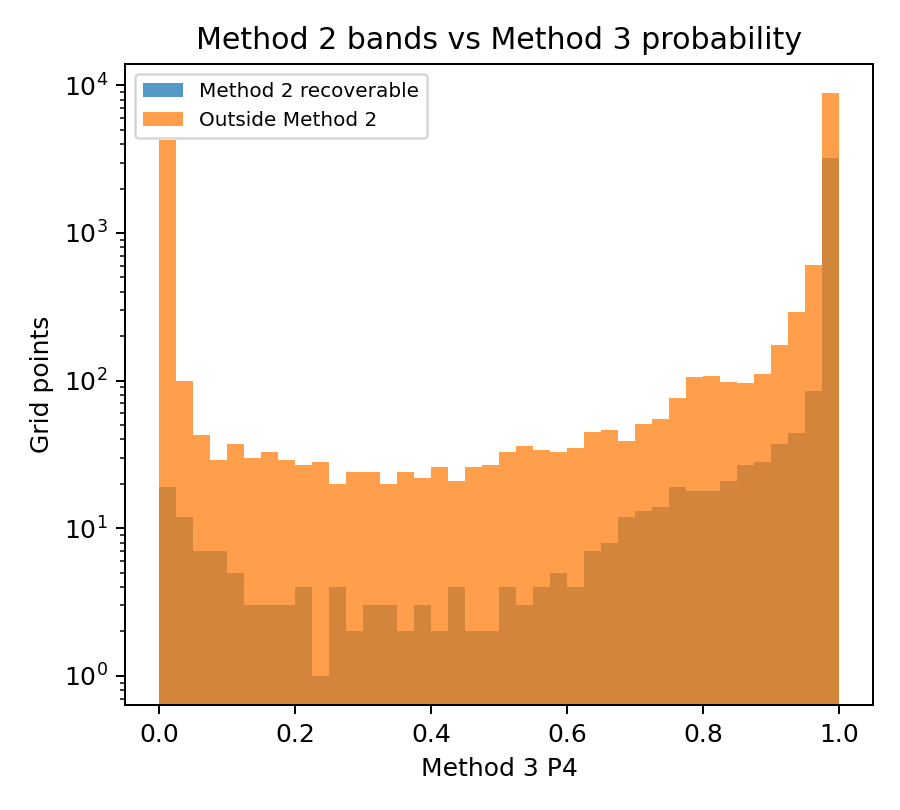

In [8]:
from IPython.display import Image, display

for path in [
    figures / "10_completeness_vs_tau.png",
    figures / "10_tau1000_completeness_vs_tau.png",
    figures / "10_tau1000_known_trap_probability_hist.png",
    figures / "10_tau1000_method2_vs_method3_hist.png",
]:
    print(path.relative_to(repo), path.exists())
    if path.exists():
        display(Image(filename=str(path)))

## Inspect The Extended Completeness Statement

This is the prose artifact Stage 10 creates from the long-tau chain.

In [9]:
print(extended["stage10_statement"].read_text(encoding="utf-8"))

# Method 3 Conditional Completeness Statement

Using the Stage 08 injection-recovery grid and the Stage 05 high-confidence amplitude prior, the Stage 09 characterization map is validated by the observed characterized traps: 99.8595% of the `n_good = 4` known traps fall at `P_4 >= 0.8`, with median `P_4 = 0.99999997`.

Averaging `P(characterized | tau_135, E)` over the observed `n_good = 4` energy distribution gives mean completeness of 1.000 at `tau_135 = 1 s`, 1.000 at `10 s`, 0.995 at `100 s`, 0.936 at `10^3 s`, and 0.688 at `10^4 s`.
The default conditional curve is at least 95% complete on the Stage 09 grid from `tau_135 = 0.000562` to `668 s`.
It is at least 90% complete from `tau_135 = 0.000398` to `1.58e+03 s`.

This is a recoverable-completeness statement, not an unconditional population bound. It assumes hidden traps share the observed `E` distribution and the observed/high-confidence trap-depth prior. Under fainter amplitude priors, the `n_good = 4` mean probability at `tau_1

## Human Interpretation Checklist

- If the long-tau `P4` map is similar to baseline, the old `20 s` Stage 08 boundary was not driving the final claim.
- If the long-tau `P4` map rises in the old dark wedge, update the Stage 10 statement and slides to use the `tau1000` chain.
- If known-trap validation degrades, inspect Stage 08 long-tau recovery curves and cutflows before trusting the rerun.
- If the all-temperatures-out-of-band region remains large, the remaining limitation is likely the actual `dtph` scan/noise/fitting cuts rather than just the old tau-grid maximum.
- The extended run still uses the same measured `dtph` values; it is not a hypothetical longer-delay experiment.